## Svm Kernels indepth intuttion and prectical Explention

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(-5.0,5.0,100) # linear space (equal distance)
y = np.sqrt(10**2-x**2) ## half circule ka formula y = √(r² - x²)
y = np.hstack([y,-y])  # horizontal stack
x = np.hstack([x,-x])

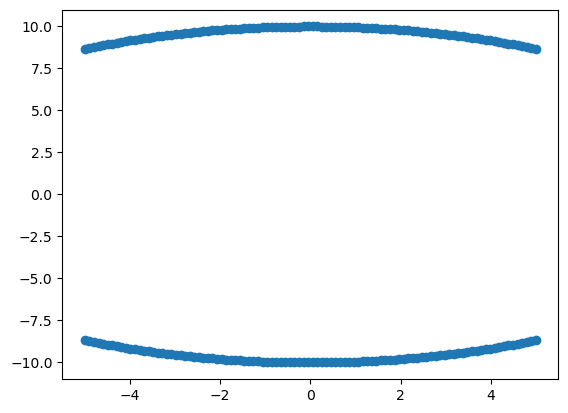

In [3]:
import matplotlib.pyplot as plt
plt.plot(x, y, 'o')  # Circle dikhega
plt.show()

In [4]:
x1 = np.linspace(-5.0,5.0,100) # linear space (equal distance)
y1 = np.sqrt(5**2-x1**2) ## half circule ka formula y = √(r² - x²)
y1 = np.hstack([y1,-y1])  # horizontal stack
x1 = np.hstack([x1,-x1])

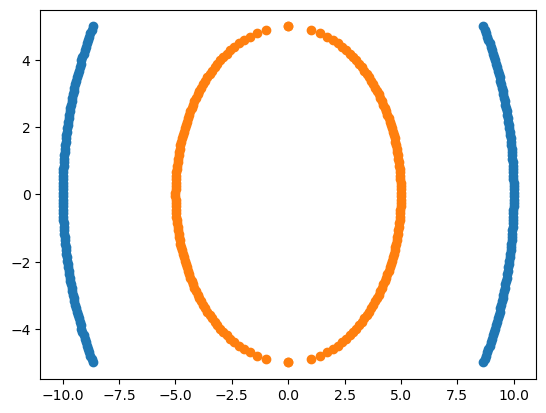

In [5]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [6]:
np.vstack([y,x]).T

array([[ 8.66025404, -5.        ],
       [ 8.71779204, -4.8989899 ],
       [ 8.77378994, -4.7979798 ],
       [ 8.82827705, -4.6969697 ],
       [ 8.88128118, -4.5959596 ],
       [ 8.93282873, -4.49494949],
       [ 8.98294476, -4.39393939],
       [ 9.03165312, -4.29292929],
       [ 9.07897646, -4.19191919],
       [ 9.12493632, -4.09090909],
       [ 9.16955321, -3.98989899],
       [ 9.21284664, -3.88888889],
       [ 9.25483518, -3.78787879],
       [ 9.29553652, -3.68686869],
       [ 9.3349675 , -3.58585859],
       [ 9.37314414, -3.48484848],
       [ 9.41008171, -3.38383838],
       [ 9.44579475, -3.28282828],
       [ 9.4802971 , -3.18181818],
       [ 9.51360192, -3.08080808],
       [ 9.54572176, -2.97979798],
       [ 9.57666854, -2.87878788],
       [ 9.60645359, -2.77777778],
       [ 9.63508769, -2.67676768],
       [ 9.66258107, -2.57575758],
       [ 9.68894344, -2.47474747],
       [ 9.714184  , -2.37373737],
       [ 9.73831149, -2.27272727],
       [ 9.76133416,

In [7]:
import pandas as pd
df1 =pd.DataFrame(np.vstack ([y,x]).T,columns=['X1','X2']) # vertically stack for spliting
df1['Y']=0 ## New Columns add  
df2 =pd.DataFrame(np.vstack ([y1,x1]).T,columns=['X1','X2']) ## Here 'T' is transport
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [8]:
## To devided to the Dependend and independed Feature
X = df.iloc[:,1]
y=df.Y

In [9]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
X_train ,X_test , y_train, y_test =train_test_split(X,y,test_size=0.25,random_state=42)

In [11]:
y_train

247    1
110    0
16     0
66     0
153    0
      ..
71     0
106    0
270    1
348    1
102    0
Name: Y, Length: 300, dtype: int64

### Polynomial kernals

In [12]:
## We need to find the polynomial componets
# X1,X2,X1_square,X2_square,X1*X2
df['X1_square']=df['X1']**2
df['X2_square']=df['X2']**2
df['X1*X2'] = (df['X1']*df['X2'])
df.head()

,X1,X2,Y,X1_square,X2_square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [13]:
## Independed feature and depended feature 
X = df[['X1','X2','X1_square','X2_square','X1*X2']]
y=df['Y']

In [14]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [15]:
X_train ,X_test , y_train, y_test =train_test_split(X,y,test_size=0.25,random_state=42)

In [16]:
X_train

,X1,X2,X1_square,X2_square,X1*X2
247,4.993619,-0.252525,24.936231,0.063769,-1.261015
110,-9.169553,3.989899,84.080706,15.919294,-36.585591
16,9.410082,-3.383838,88.549638,11.450362,-31.842196
66,9.860133,1.666667,97.222222,2.777778,16.433555
153,-9.993749,-0.353535,99.875013,0.124987,3.533143
...,...,...,...,...,...
71,9.761334,2.171717,95.283645,4.716355,21.198857
106,-8.982945,4.393939,80.693297,19.306703,-39.470515
270,4.551063,2.070707,20.712172,4.287828,9.423918
348,-4.997704,0.151515,24.977043,0.022957,-0.757228


In [17]:
import plotly.express as px
fig  = px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')
fig.show(renderer="browser")

In [18]:
fig  = px.scatter_3d(df,x='X1_square',y='X1_square',z='X1*X2',color='Y')
fig.show(renderer="browser")

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [20]:
classifire = SVC(kernel='linear')
classifire.fit(X_train,y_train)
y_pred =classifire.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [21]:
classifire = SVC(kernel='poly')
classifire.fit(X_train,y_train)
y_pred =classifire.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [22]:
classifire = SVC(kernel='rbf')
classifire.fit(X_train,y_train)
y_pred =classifire.predict(X_test)
accuracy_score(y_test,y_pred)    

1.0